# Maps

In [38]:
!pip install pylandstats 

In [39]:
import warnings
warnings.filterwarnings("ignore")

# Graphics
import matplotlib.pyplot as plt
from matplotlib import colors

#Data handling
import shapely
from shapely.wkt import loads

# Analysis
import numpy as np
import geopandas as gpd
import pandas as pd
import statsmodels.formula.api as smf  #https://www.statsmodels.org/dev/api.html#statsmodels-formula-api
import statsmodels.api as sm

from pysal.model import spreg
from libpysal import weights
from pysal.explore import esda
import rasterio

In [40]:
master_gdf = gpd.read_file ('aggregated data/master_file.geojson')

In [41]:
print(master_gdf.columns)

Index(['LAD21CD', 'LAD21NM', 'LAD21NMW', 'BNG_E', 'BNG_N', 'LONG', 'LAT',
       'GlobalID', 'Health_Pct_Change', 'YAge_Pct_Change', 'Pct_VATP_11_21',
       'Mig_Change', 'geometry'],
      dtype='object')


## Health Map

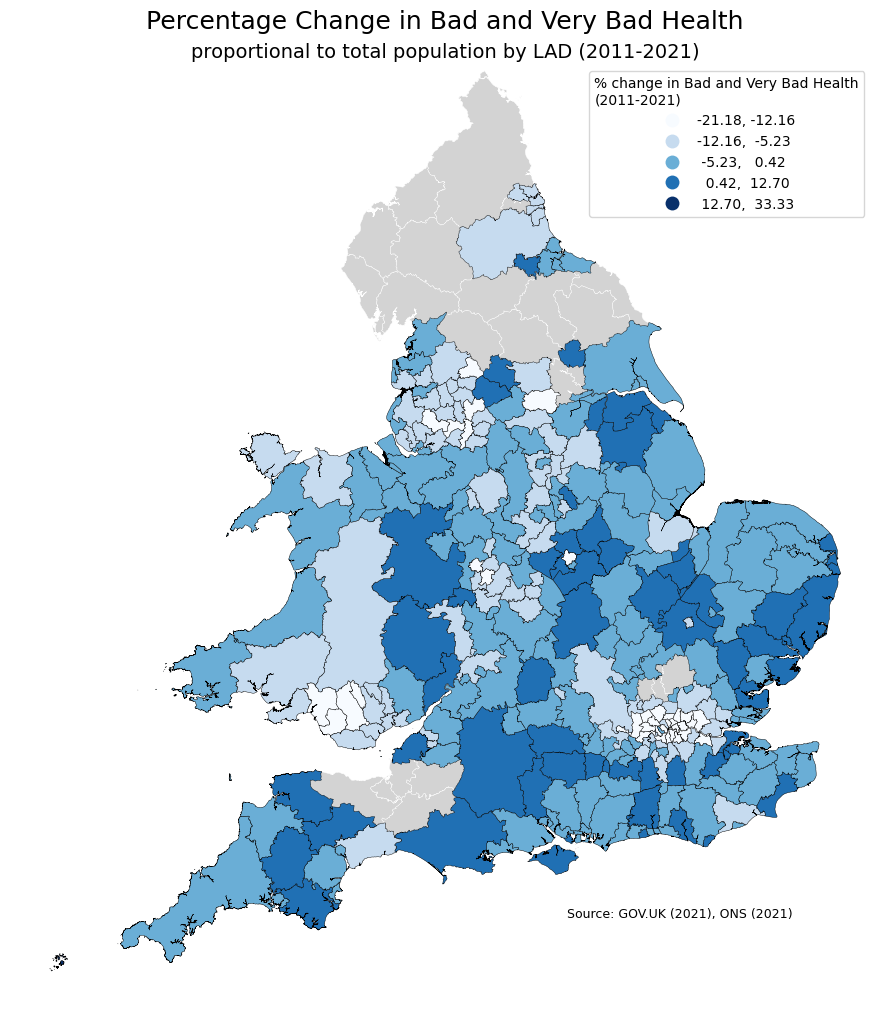

In [52]:
plt.rcParams['font.family'] = 'DejaVu Sans'
fig, ax = plt.subplots(1, 1, figsize=(9, 12))

#colour for missing data
master_gdf.plot(ax=ax, color='#D3D3D3', edgecolor='white', linewidth=0.3)

master_gdf.plot(
    column='Health_Pct_Change',
    cmap='Blues',
    scheme='FisherJenks',
    k=5,
    linewidth=0.3,
    edgecolor='black',
    legend=True,
    legend_kwds={'title':'% change in Bad and Very Bad Health\n(2011-2021)',
                'loc':'lower right',
                'bbox_to_anchor':(0.99,0.8)},
    ax=ax
)

fig.suptitle("Percentage Change in Bad and Very Bad Health", size=18, x=0.5, y=0.910)
fig.text(0.5, 0.87, "proportional to total population by LAD (2011-2021)", ha='center', fontsize=14)
ax.annotate("Source: GOV.UK (2021), ONS (2021)", xy=(0.64, 0.1), xycoords='axes fraction', fontsize=9)
ax.set_axis_off()
plt.tight_layout()
plt.show()
fig.savefig('Health_Map.jpg',dpi=150,bbox_inches='tight',facecolor='white')

## Age Map

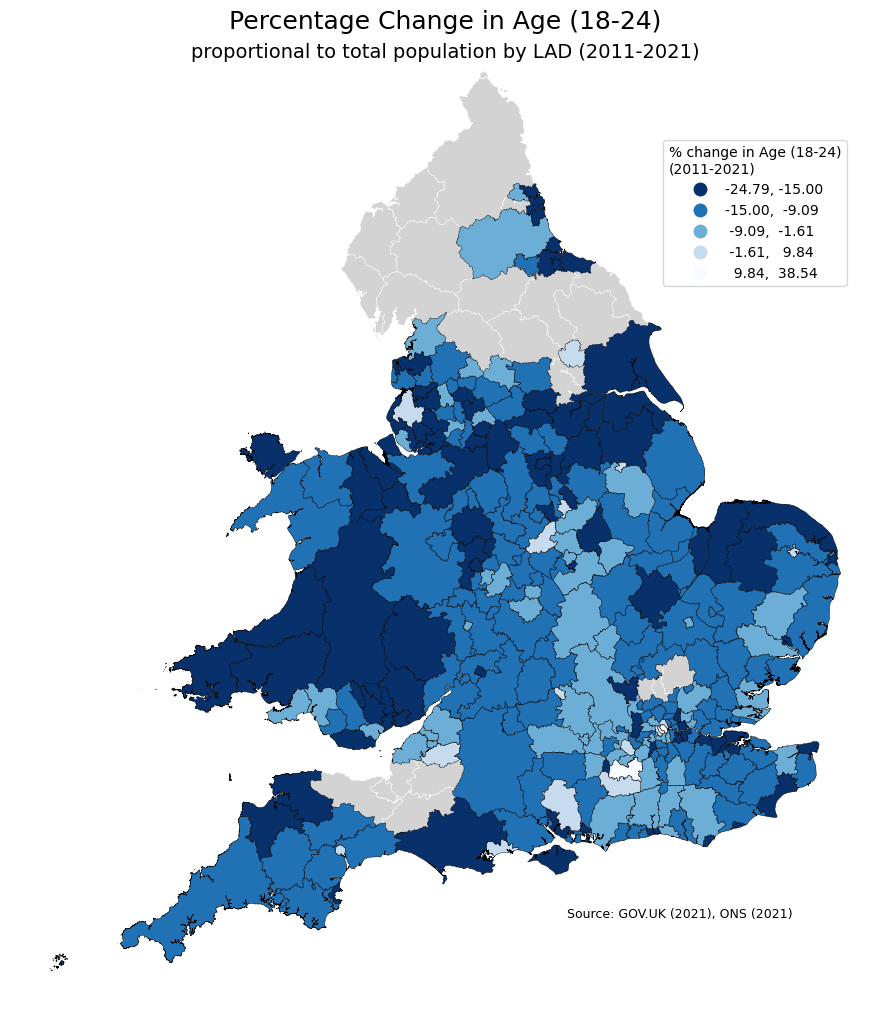

In [53]:
plt.rcParams['font.family'] = 'DejaVu Sans'
fig, ax = plt.subplots(1, 1, figsize=(9, 12))

#colour for missing data
master_gdf.plot(ax=ax, color='#D3D3D3', edgecolor='white', linewidth=0.3)

master_gdf.plot(
    column='YAge_Pct_Change',
    cmap='Blues_r',
    scheme='FisherJenks',
    k=5,
    linewidth=0.3,
    edgecolor='black',
    legend=True,
    legend_kwds={'title':'% change in Age (18-24)\n(2011-2021)',
                'loc':'lower right',
                'bbox_to_anchor':(0.97,0.73)},
    ax=ax
)

fig.suptitle("Percentage Change in Age (18-24)", size=18, x=0.5, y=0.910)
fig.text(0.5, 0.87, "proportional to total population by LAD (2011-2021)", ha='center', fontsize=14)
ax.annotate("Source: GOV.UK (2021), ONS (2021)", xy=(0.64, 0.1), xycoords='axes fraction', fontsize=9)
ax.set_axis_off()
plt.tight_layout()
plt.show()
fig.savefig('Age_Map.jpg',dpi=150,bbox_inches='tight',facecolor='white')

## Migration

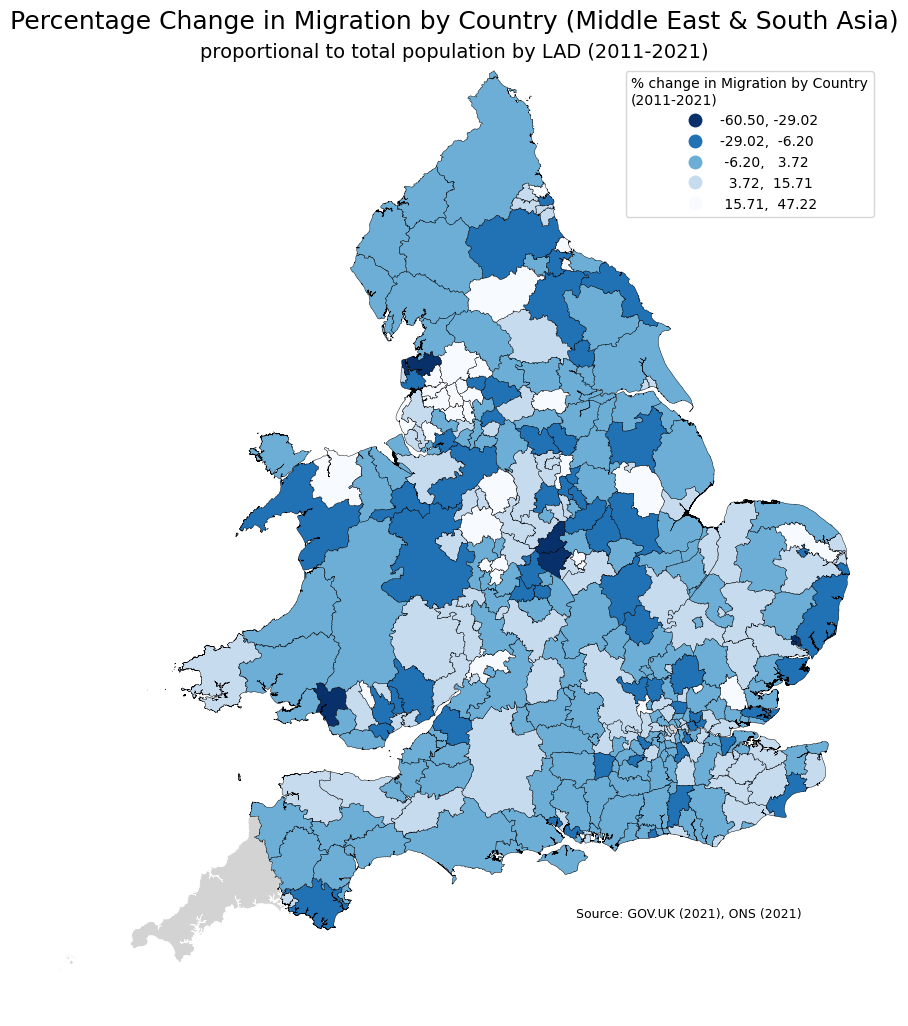

In [44]:
plt.rcParams['font.family'] = 'DejaVu Sans'
fig, ax = plt.subplots(1, 1, figsize=(9, 12))

#colour for missing data
master_gdf.plot(ax=ax, color='#D3D3D3', edgecolor='white', linewidth=0.3)

master_gdf.plot(
    column='Mig_Change',
    cmap='Blues_r',
    scheme='FisherJenks',
    k=5,
    linewidth=0.3,
    edgecolor='black',
    legend=True,
    legend_kwds={'title':'% change in Migration by Country\n(2011-2021)',
                'loc':'lower right',
                'bbox_to_anchor':(0.99,0.8)},
    ax=ax
)

fig.suptitle("Percentage Change in Migration by Country (Middle East & South Asia)", size=18, x=0.5, y=0.910)
fig.text(0.5, 0.87, "proportional to total population by LAD (2011-2021)", ha='center', fontsize=14)
ax.annotate("Source: GOV.UK (2021), ONS (2021)", xy=(0.64, 0.1), xycoords='axes fraction', fontsize=9)
ax.set_axis_off()
plt.tight_layout()
plt.show()
fig.savefig('Migration_Map.jpg',dpi=150,bbox_inches='tight',facecolor='white')

## Violent Crime 

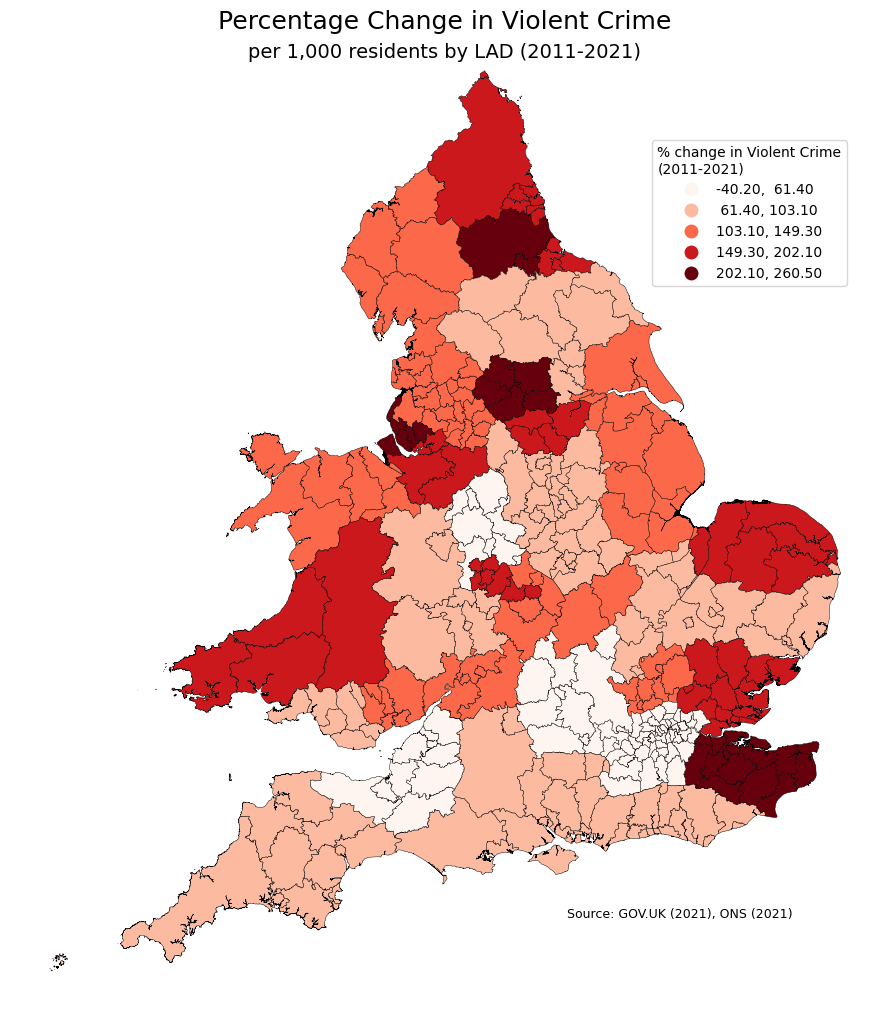

In [45]:
plt.rcParams['font.family'] = 'DejaVu Sans'
fig, ax = plt.subplots(1, 1, figsize=(9, 12))

#colour for missing data
master_gdf.plot(ax=ax, color='#D3D3D3', edgecolor='white', linewidth=0.3)

master_gdf.plot(
    column='Pct_VATP_11_21',
    cmap='Reds',
    scheme='FisherJenks',
    k=5,
    linewidth=0.3,
    edgecolor='black',
    legend=True,
    legend_kwds={'title':'% change in Violent Crime\n(2011-2021)',
                'loc':'lower right',
                'bbox_to_anchor':(0.97,0.73)},
    ax=ax
)

fig.suptitle("Percentage Change in Violent Crime", size=18, x=0.5, y=0.910)
fig.text(0.5, 0.87, "per 1,000 residents by LAD (2011-2021)", ha='center', fontsize=14)
ax.annotate("Source: GOV.UK (2021), ONS (2021)", xy=(0.64, 0.1), xycoords='axes fraction', fontsize=9)
ax.set_axis_off()
plt.tight_layout()
plt.show()
fig.savefig('Crime_Map.jpg',dpi=150,bbox_inches='tight',facecolor='white')